# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовим аналитическую записку, в которой опишим:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

### Цели и задачи проекта



<font color='#777778'>
    
    
**Цель проекта**: 
    Оценить поведение пользователей в сервисе Я.Книги и эффективность изменений интерфейса интернет-магазина BitMotion Kit с точки зрения активности пользователей, LTV и конверсии.
    
**Задачи проекта**:
1. **Анализ активности пользователей Я.Книг:**  
   - Рассчитать ключевые метрики (MAU, LTV, суммарное время активности).  
   - Сравнить поведение пользователей по городам (Москва и Санкт-Петербург).  

2. **Проверка гипотезы о лояльности пользователей:**  
   - Проверить, проводят ли пользователи из Санкт-Петербурга больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.  
   - Использовать статистический односторонний t-тест для сравнения средних значений.  

3. **Анализ результатов A/B-тестирования интернет-магазина BitMotion Kit:**  
   - Оценить корректность проведения теста и распределение пользователей по группам.  
   - Проверить влияние нового интерфейса на конверсию зарегистрированных пользователей в покупателей.   
    
</font>

### Описание данных

<font color='#777778'>1. Таблица `ab_test_participants` – участники A/B-теста
- `user_id` — идентификатор пользователя  
- `group` — группа пользователя (`A` — контрольная, `B` — новый интерфейс)  
- `ab_test` — название теста (`interface_eu_test`)  
- `device` — устройство, с которого происходила регистрация  
- Источник: [CSV файл участников теста](https://code.s3.yandex.net/datasets/ab_test_participants.csv)

2. Таблица `ab_test_events` – события пользователей
- `user_id` — идентификатор пользователя  
- `event_dt` — дата и время события  
- `event_name` — тип события (`registration`, `purchase` и др.)  
- `details` — дополнительные данные о событии  

**Дополнительная информация по столбцу `details`:**  
- `registration` — стоимость привлечения клиента  
- `purchase` — стоимость покупки  

- Источник: [ZIP с CSV файлами событий](https://code.s3.yandex.net/datasets/ab_test_events.zip)

- `Текстовые значения`:
| Код  | Зона                  |
|------|----------------------|
| 0    | ZONE_CODE00 / None   |
| 1    | ZONE_CODE01 / EU     |
| 2    | ZONE_CODE02 / CIS    |
| 3    | ZONE_CODE03 / EU, CIS|
| 4    | ZONE_CODE04 / APAC   |
| 5    | ZONE_CODE05 / EU, APAC|
| 6    | ZONE_CODE06 / CIS, APAC|
| 7    | ZONE_CODE07 / EU, CIS, APAC|
| 8    | ZONE_CODE08 / N.America|
| 9    | ZONE_CODE09 / EU, N.America|
| 10   | ZONE_CODE10 / CIS, N.America|
| 11   | ZONE_CODE11 / EU, CIS, N.America|
| 12   | ZONE_CODE12 / APAC, N.America|
| 13   | ZONE_CODE13 / EU, APAC, N.America|
| 14   | ZONE_CODE14 / CIS, APAC, N.America|
| 15   | ZONE_CODE15 / EU, CIS, APAC, N.America|</font>

## Содержимое проекта

<font color='#777778'>
1.Загрузка данных и знакомство с ними
2. Предобработка данных
3. Проверка гипотезы в Python
4. Аналитическая записка по результатам гипотезы
5. Анализ результатов A/B-тестирования BitMotion Kit
6. Вывод </font>

---

## 1. Загрузка данных и знакомство с ними

In [3]:
# Импорт библиотек
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [25]:
# Загрузка данных
data = pd.read_csv('/datasets/yandex_knigi_data.csv')

# Размер данных и типы столбцов
data.info()

# Просмотр первых 5 строк
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [26]:
# Убираем  лишний столбец "Unnamed: 0" и используем первый столбец как индекс
data = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)

# Размер данных и типы столбцов
data.info()

# Просмотр первых 5 строк
data.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [27]:
# Проверка на пропущенные значения
data.isnull().sum()

city     0
puid     0
hours    0
dtype: int64

Пропуски в данных отстуствуют.

In [ ]:
# Проверка на дубликаты по всем столбцам
duplicates_all = data.duplicated()
print("Количество полностью дублирующихся строк:", duplicates_all.sum())

# Проверка на дубликаты только по идентификатору пользователя (puid)
duplicates_puid = data.duplicated(subset=['puid'])
print("Количество повторяющихся пользователей (puid):", duplicates_puid.sum())

In [29]:
# Агрегируем данные по пользователю
user_hours = data.groupby(['city', 'puid'], as_index=False)['hours'].sum()
user_hours.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [30]:
# Убираем дубликаты по пользователю, оставляем первую запись
user_hours_unique = user_hours.drop_duplicates(subset=['puid'], keep='first')

# Проверим, сколько пользователей осталось
print("Количество уникальных пользователей:", user_hours_unique.shape[0])

Количество уникальных пользователей: 8540


In [31]:
# Разделяем пользователей по городам
moscow_users = user_hours_unique[user_hours_unique['city'] == 'Москва']['hours']
spb_users = user_hours_unique[user_hours_unique['city'] == 'Санкт-Петербург']['hours']

# Размеры групп
print("Количество пользователей в Москве:", len(moscow_users))
print("Количество пользователей в Санкт-Петербурге:", len(spb_users))

# Статистики для каждой группы
print("\nСтатистики по Москве:")
print(moscow_users.describe())

print("\nСтатистики по Санкт-Петербургу:")
print(spb_users.describe())

Количество пользователей в Москве: 6234
Количество пользователей в Санкт-Петербурге: 2306

Статистики по Москве:
count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

Статистики по Санкт-Петербургу:
count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64


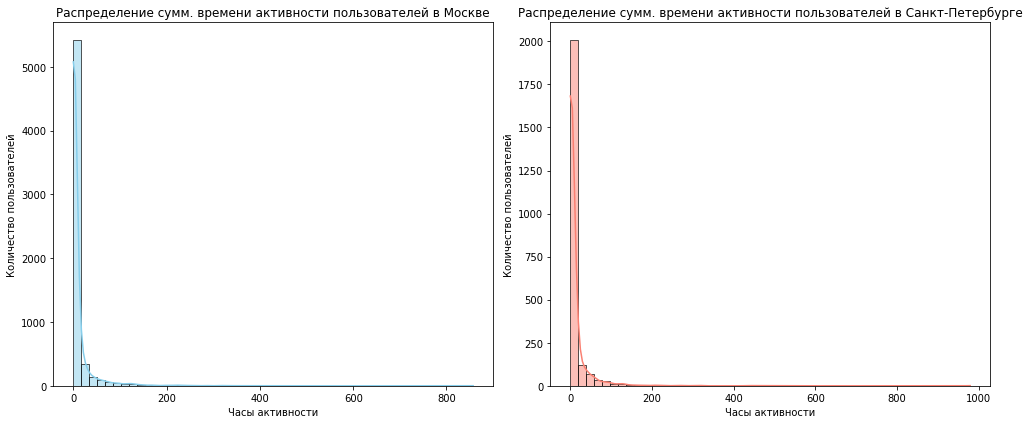

In [32]:
# Настройки графиков

plt.figure(figsize=(14,6))

# Гистограмма для Москвы
plt.subplot(1, 2, 1)
sns.histplot(moscow_users, bins=50, kde=True, color='skyblue')
plt.title('Распределение сумм. времени активности пользователей в Москве')
plt.xlabel('Часы активности')
plt.ylabel('Количество пользователей')

# Гистограмма для Санкт-Петербурга
plt.subplot(1, 2, 2)
sns.histplot(spb_users, bins=50, kde=True, color='salmon')
plt.title('Распределение сумм. времени активности пользователей в Санкт-Петербурге')
plt.xlabel('Часы активности')
plt.ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

Данные подготовлены и очищены от дубликатов, выборки по городам готовы для последующего статистического анализа и проверки гипотезы.
- Среднее значение в СПБ немного выше, чем в Москве (11.26 vs 10.88)
- Распределения в обеих группах резко правосторонние, с длинным хвостом
- Медианы почти одинаковы, активность большинства пользователей похожа
- Различия могут быть обусловлены выбросами

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [33]:
# Подготовка данных для теста
mos_data = moscow_users.dropna().astype(float)
spb_data = spb_users.dropna().astype(float)

print("Размер выборок:")
print(f"  Москва: {mos_data.shape[0]}")
print(f"  СПб:    {spb_data.shape[0]}\n")

# Базовое сравнение статистик
print("Средние значения:")
print(f"  Москва: {mos_data.mean():.3f}")
print(f"  СПб:    {spb_data.mean():.3f}\n")

# Проверка равенства дисперсий: тест Левена
lev_stat, lev_p = stats.levene(mos_data, spb_data)

print(f"Тест Левена на равенство дисперсий: p-value = {lev_p:.4f}")

# Если p < 0.05, дисперсии разные → equal_var=False
use_equal_var = lev_p >= 0.05

# Двусторонний t-тест
t_res = stats.ttest_ind(spb_data, mos_data, equal_var=use_equal_var)

t_value = t_res.statistic
p_two_sided = t_res.pvalue

# Односторонний тест: СПб > Москва
if spb_data.mean() > mos_data.mean():
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1.0

print("\nРезультаты t-теста:")
print(f"t-статистика: {t_value:.3f}")
print(f"p-value (односторонний): {p_one_sided:.5f}")

alpha = 0.05


if p_one_sided < alpha:
    print("Отвергаем H₀: данные позволяют предположить,"
          " что пользователи СПб проводят больше времени в приложении.")
else:
    print("Не удалось отвергнуть H₀: статистически значимых доказательств"
          " большей активности СПб не найдено.")

Размер выборок:
  Москва: 6234
  СПб:    2306

Средние значения:
  Москва: 10.881
  СПб:    11.264

Тест Левена на равенство дисперсий: p-value = 0.6679

Результаты t-теста:
t-статистика: 0.417
p-value (односторонний): 0.33819
Не удалось отвергнуть H₀: статистически значимых доказательств большей активности СПб не найдено.


## 3. Аналитическая записка


1. `Тип теста и уровень значимости`:
Мы использовали односторонний t-тест для независимых выборок (unequal variance не применялось, так как дисперсии примерно равны, проверка тестом Левена дала p > 0.05).
Уровень статистической значимости: α = 0.05.
2. `Результат теста`:
- t-статистика = 0.417
- p-value (односторонний) = 0.338
3. На основании полученного p-value нет статистически значимых доказательств, что пользователи Санкт-Петербурга проводят больше времени в приложении, чем пользователи Москвы. Средние значения немного выше у СПб, но разница может быть случайной.

4. `Возможные причины полученного результата`:
- Большая часть пользователей в обоих городах проводит мало времени в приложении, а среднее немного смещается из-за редких очень активных пользователей (выбросов).
- Поведение пользователей в Москве и Санкт-Петербурге может быть схожим, так как сервис одинаково популярен и доступен в обоих городах.

----

# Часть 2. Анализ результатов A/B-тестирования

Обратились  представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Наша задача — провести оценку результатов A/B-теста. В нашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

## 1. Опишите цели исследования.



1. `Оценить корректность проведения A/B-теста`:
- Проверить, равномерно ли распределены пользователи по контрольной (A) и экспериментальной (B) группам.
- Убедиться, что нет технических или логических ошибок в данных (повторы, пропуски, некорректные значения).
2.	`Проверить влияние нового интерфейса на поведение пользователей`:
- Сравнить долю пользователей, совершивших покупку, в группах A и B.
- Определить, есть ли статистически значимое увеличение конверсии у пользователей, которые видели новый интерфейс.
3.	`Выявить потенциальные рекомендации для бизнеса`:
- На основе результатов теста дать практические рекомендации: внедрять новый интерфейс, доработать или оставить старый.

____

## 2. Загрузите данные, оцените их целостность.


In [13]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [14]:
participants.info()
participants.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [15]:
print("Уникальных тестов:", participants['ab_test'].unique())
print("Уникальных групп в тестах:", participants['group'].unique())

Уникальных тестов: ['interface_eu_test' 'recommender_system_test']
Уникальных групп в тестах: ['B' 'A']


In [16]:
participants.duplicated().sum()

0

Данные участников теста чистые и готовы к дальнейшему анализу. Можно переходить к оценке корректности распределения пользователей по группам и анализу конверсии.

____

## 3. По таблице `ab_test_participants` оценим корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [17]:
# Фильтруем участников только интересующего нас теста
interface_test = participants[participants['ab_test'] == 'interface_eu_test'].copy()

# Проверяем уникальные группы
print("Группы в тесте:", interface_test['group'].unique())

# Проверяем количество пользователей в каждой группе
group_counts = interface_test['group'].value_counts()
print("\nКоличество пользователей по группам:")
print(group_counts)


Группы в тесте: ['B' 'A']

Количество пользователей по группам:
B    5467
A    5383
Name: group, dtype: int64


In [18]:
# Проверка, есть ли пользователи, участвующие одновременно в двух группах (A и B) одного теста
duplicates_in_test = interface_test.groupby('user_id')['group'].nunique()
overlapping_users = duplicates_in_test[duplicates_in_test > 1].count()
print("\nПользователи, участвующие в двух группах одного теста:", overlapping_users)

#  Проверка пересечения с другим тестом (чтобы исключить влияние конкурирующего теста)
# Сначала получаем пользователей, участвующих в другом тесте
other_test_users = participants[participants['ab_test'] == 'recommender_system_test']['user_id'].unique()

# Смотрим пересечение
intersection_count = interface_test['user_id'].isin(other_test_users).sum()
print("Пользователи, одновременно участвующие в конкурирующем тесте:", intersection_count)


Пользователи, участвующие в двух группах одного теста: 0
Пользователи, одновременно участвующие в конкурирующем тесте: 887


3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [19]:
# Выбираем участников интересующего теста
test_name = 'interface_eu_test'
test_participants = participants[participants['ab_test'] == test_name].copy()

# Исключаем участников других тестов
other_test_users = participants[participants['ab_test'] != test_name]['user_id'].unique()
test_participants = test_participants[~test_participants['user_id'].isin(other_test_users)]

# Фильтруем события участников теста
test_events = events[events['user_id'].isin(test_participants['user_id'])].copy()
test_events = test_events[test_events['user_id'].notna()]

# Присоединяем информацию о группе и устройстве
test_events = test_events.merge(
    test_participants[['user_id', 'group', 'device']],
    on='user_id',
    how='left'
)

# Проверяем и удаляем дубликаты
print(f"Общее число событий до удаления дубликатов: {len(test_events)}")
print(f"Количество полностью дублирующихся строк: {test_events.duplicated().sum()}")
test_events_clean = test_events.drop_duplicates()
print(f"Общее число событий после удаления дубликатов: {len(test_events_clean)}")
print(f"Уникальных пользователей: {test_events_clean['user_id'].nunique()}")

Общее число событий до удаления дубликатов: 73815
Количество полностью дублирующихся строк: 5741
Общее число событий после удаления дубликатов: 68074
Уникальных пользователей: 9963


- определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [34]:
# Список событий для анализа воронки
important_events = ['registration', 'login', 'product_page', 'product_cart', 'purchase']

# Получаем дату первой регистрации каждого пользователя
reg_times = test_events_clean[test_events_clean['event_name'] == 'registration'] \
    .groupby('user_id')['event_dt'].min().rename('reg_time')

# Присоединяем дату регистрации ко всем событиям
events_with_reg = test_events_clean.merge(
    reg_times,
    left_on='user_id',
    right_index=True,
    how='left'
)

# Оставляем только события, которые произошли в первые 7 дней после регистрации
events_7d = events_with_reg[
    (events_with_reg['reg_time'].notna()) &  # только пользователи с регистрацией
    (events_with_reg['event_dt'] >= events_with_reg['reg_time']) &
    (events_with_reg['event_dt'] <= events_with_reg['reg_time'] + pd.Timedelta(days=7))
].copy()

# Строим воронку: число уникальных пользователей, совершивших каждое событие в каждой группе
funnels = {}
for ev in important_events:
    counts = events_7d[events_7d['event_name'] == ev].groupby('group')['user_id'].nunique()
    funnels[ev] = counts

funnels_df = pd.DataFrame(funnels).T.fillna(0).astype(int)
print("Воронка по событиям в первые 7 дней:\n")
print(funnels_df)

# Оценка достаточности выборки для статистически значимых результатов A/B-теста
alpha = 0.05      # уровень значимости 95%
power = 0.8       # мощность теста 80%
p1 = 0.30         # базовая конверсия
mdes = [0.01, 0.02, 0.03, 0.05, 0.10]  # минимально заметные эффекты (MDE)

Воронка по событиям в первые 7 дней:

group            A     B
registration  4952  5011
login         4952  5010
product_page  3107  3184
product_cart  1395  1327
purchase      1377  1480


Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [35]:
alpha = 0.05
power = 0.8
p1 = 0.30
mdes = [0.01, 0.02, 0.03, 0.05, 0.10]

pw = NormalIndPower()
for delta in mdes:
    p2 = p1 + delta
    effect = proportion_effectsize(p1, p2)  # Cohen's h
    n_per_group = pw.solve_power(effect, power=power, alpha=alpha, ratio=1, alternative='two-sided')
    print(f"MDE {delta*100:.1f} pp -> n per group ≈ {int(np.ceil(n_per_group))}")

MDE 1.0 pp -> n per group ≈ 33274
MDE 2.0 pp -> n per group ≈ 8393
MDE 3.0 pp -> n per group ≈ 3762
MDE 5.0 pp -> n per group ≈ 1376
MDE 10.0 pp -> n per group ≈ 356


- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [22]:
# Рассчет конверсии по покупкам
total_7d = events_7d.groupby('group')['user_id'].nunique().rename('total_users_7d')
purchasers_7d = (events_7d[events_7d['event_name'] == 'purchase']
                 .groupby('group')['user_id'].nunique()
                 .rename('purchasers_7d'))

summary_7d = pd.concat([total_7d, purchasers_7d], axis=1).fillna(0).astype(int)
summary_7d['conversion_7d'] = summary_7d['purchasers_7d'] / summary_7d['total_users_7d']

print("\nСводка по конверсии за 7 дней:\n")
print(summary_7d)

# Расчет абсолютного и относительного изменения конверсии
conv_A = summary_7d.loc['A', 'conversion_7d']
conv_B = summary_7d.loc['B', 'conversion_7d']

abs_change = (conv_B - conv_A) * 100         # в процентных пунктах
rel_change = (conv_B - conv_A) / conv_A * 100  # в процентах

print(f"\nАбсолютное изменение конверсии (п.п.): {abs_change:.2f}")
print(f"Относительное изменение конверсии (%): {rel_change:.2f}")


Сводка по конверсии за 7 дней:

       total_users_7d  purchasers_7d  conversion_7d
group                                              
A                4952           1377       0.278069
B                5011           1480       0.295350

Абсолютное изменение конверсии (п.п.): 1.73
Относительное изменение конверсии (%): 6.21


- сделаем предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

В тестовой группе (B) конверсия в покупку за первые 7 дней выросла с 27,8% до 29,5% относительно контрольной группы (A), что соответствует абсолютному приросту +1,7 п.п. и относительному увеличению +6,2%. Пользовательская активность в тестовой группе выше, чем в контрольной.

## 4. Проведем оценку результатов A/B-тестирования:

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Определяем гипотезы
- H₀ (нулевая гипотеза): конверсия в покупку одинакова в группах A и B.
- H₁ (альтернативная гипотеза): конверсия в покупку в тестовой группе B отличается от контрольной A.

In [23]:
# Количество покупателей в каждой группе
successes = summary_7d['purchasers_7d'].values  # [A, B]

# Общее количество уникальных пользователей в каждой группе
nobs = summary_7d['total_users_7d'].values       # [A, B]
z_stat, p_value = proportions_ztest(count=successes, nobs=nobs, alternative='two-sided')

print(f"z-statistic = {z_stat:.3f}")
print(f"p-value = {p_value:.3f}")

z-statistic = -1.907
p-value = 0.057


- Конверсия за 7 дней: A — 27,8%, B — 29,5% (+1,73 п.п., +6,2%).
- Статистическая проверка: двусторонний z-тест p = 0,057 → при α=0,05 статистически значимой разницы нет.
- Практически: тестовая версия интерфейса показывает рост активности пользователей.
- Рекомендация: рассмотреть внедрение с учётом затрат и потенциального дохода.